# AgriMind Phase 3: Fertilizer Supply / Sales Time-Series Prediction using RNN, LSTM, and GRU

This notebook is prepared according to the AgriMind proposal and submission guideline requirements.

Your current dataset folder structure is:

```text
E:\AI Project\AgriMind_Project\datasets\Fertilizer_Dataset
├── fertiliser_production_capacity_2014_to_2024.csv
└── requirement_availability_sales_fertilisers_2014_to_2024.csv
```

## What this notebook does

1. Loads both fertilizer datasets from your exact local folder.
2. Shows dataset source and dataset characteristics.
3. Performs preprocessing:
   - importing libraries
   - importing datasets
   - handling missing values
   - handling duplicate records
   - treating outliers
   - feature scaling
   - handling categorical variables where needed
   - train-test split
4. Uses a time-series feature selection approach.
5. Trains three models:
   - RNN
   - LSTM
   - GRU
6. Evaluates models using:
   - MAE
   - MSE
   - RMSE
   - MAPE
   - R² Score
7. Saves:
   - models
   - results
   - graphs
   - preprocessing report

## Important note

Your given dataset names do not explicitly say `price`. They include fertilizer production capacity, requirement, availability, and sales. So this notebook predicts a fertilizer **supply/sales trend**. In the presentation/report, you can explain this as the supply-chain optimization forecasting part of AgriMind.

In [1]:
# ============================================================
# Block 1: Import libraries and set environment
# ============================================================

import os
import sys
import json
import math
import pickle
import subprocess
import warnings

warnings.filterwarnings("ignore")

# Reduce TensorFlow CPU/thread crash risk on Windows
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "1")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "1")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow"
}

for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU available: []


In [2]:
# ============================================================
# Block 2: Define exact local project and dataset paths
# ============================================================

PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

DATASET_DIR = os.path.join(PROJECT_DIR, "datasets", "Fertilizer_Dataset")

PRODUCTION_CAPACITY_FILE = os.path.join(
    DATASET_DIR,
    "fertiliser_production_capacity_2014_to_2024.csv"
)

REQUIREMENT_AVAILABILITY_SALES_FILE = os.path.join(
    DATASET_DIR,
    "requirement_availability_sales_fertilisers_2014_to_2024.csv"
)

MODEL_DIR = os.path.join(PROJECT_DIR, "models", "phase3_fertilizer_timeseries")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results", "phase3_fertilizer_timeseries")
SCREENSHOTS_DIR = os.path.join(PROJECT_DIR, "screenshots", "phase3_fertilizer_timeseries")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Project directory exists:", os.path.exists(PROJECT_DIR))
print("Fertilizer dataset folder exists:", os.path.exists(DATASET_DIR))
print("Production capacity file exists:", os.path.exists(PRODUCTION_CAPACITY_FILE))
print("Requirement/availability/sales file exists:", os.path.exists(REQUIREMENT_AVAILABILITY_SALES_FILE))

print()
print("Dataset folder:", DATASET_DIR)
print("Production capacity file:", PRODUCTION_CAPACITY_FILE)
print("Requirement/availability/sales file:", REQUIREMENT_AVAILABILITY_SALES_FILE)

if not os.path.exists(PRODUCTION_CAPACITY_FILE):
    raise FileNotFoundError(f"Missing file: {PRODUCTION_CAPACITY_FILE}")

if not os.path.exists(REQUIREMENT_AVAILABILITY_SALES_FILE):
    raise FileNotFoundError(f"Missing file: {REQUIREMENT_AVAILABILITY_SALES_FILE}")

Project directory exists: True
Fertilizer dataset folder exists: True
Production capacity file exists: True
Requirement/availability/sales file exists: True

Dataset folder: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Dataset
Production capacity file: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Dataset\fertiliser_production_capacity_2014_to_2024.csv
Requirement/availability/sales file: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Dataset\requirement_availability_sales_fertilisers_2014_to_2024.csv


In [3]:
# ============================================================
# Block 3: Load both fertilizer datasets
# ============================================================

production_df_original = pd.read_csv(PRODUCTION_CAPACITY_FILE)
sales_df_original = pd.read_csv(REQUIREMENT_AVAILABILITY_SALES_FILE)

print("Production capacity dataset shape:", production_df_original.shape)
display(production_df_original.head())

print()
print("Requirement/availability/sales dataset shape:", sales_df_original.shape)
display(sales_df_original.head())

Production capacity dataset shape: (55, 17)


,sector,state,city,company,manufacturing_unit,fertiliser_type,fy_2014_15,fy_2015_16,fy_2016_17,fy_2017_18,fy_2018_19,fy_2019_20,fy_2020_21,fy_2021_22,fy_2022_23,fy_2023_24,fy_2024_25
0,public,Haryana,panipat,National Fertilizes Ltd.,National Fertilizers Ltd Panipat,Urea,5.12,5.67,5.43,5.60,5.74,5.52,5.83,4.69,5.70,5.30,4.56
1,public,Madhya Pradesh,vijaipur,National Fertilizes Ltd.,National Fertilizers Ltd Vijaipur-I,Urea,9.51,9.90,10.58,10.44,10.29,9.84,9.66,10.41,10.50,10.43,8.84
2,public,Madhya Pradesh,vijaipur,National Fertilizes Ltd.,National Fertilizers Ltd Vijaipur-II,Urea,11.38,11.46,11.39,10.88,11.32,10.53,11.27,9.55,11.87,11.24,10.60
3,public,Punjab,nangal,National Fertilizes Ltd.,National FertilizersLtd Nangal-II,Urea,4.79,5.46,5.02,5.43,5.41,5.75,5.47,5.32,5.45,5.21,4.88
4,public,Punjab,bhatinda,National Fertilizes Ltd.,NationalFertilizers Ltd Bhatinda,Urea,5.61,5.48,5.68,5.63,5.84,5.63,5.77,5.29,5.82,4.72,4.98



Requirement/availability/sales dataset shape: (407, 15)


,financial_year,state_code,states,requirement_urea,availability_urea,sales_urea,requirement_dap,availability_dap,sales_dap,requirement_mop,availability_mop,sales_mop,requirement_npks,availability_npks,sales_npks
0,2014-15,1.0,Andaman & Nicobar,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.00,0.00
1,2014-15,2.0,Andhra Pradesh,18.27,18.54,18.07,5.52,3.13,2.94,2.94,2.77,2.54,13.84,13.40,12.51
2,2014-15,3.0,Arunachal Pradesh,0.02,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00
3,2014-15,4.0,Assam,3.15,3.19,3.16,0.45,0.37,0.33,1.25,0.79,0.67,0.10,0.13,0.11
4,2014-15,5.0,Bihar,19.00,19.43,19.40,4.60,3.66,3.53,1.55,1.77,1.54,2.75,2.87,2.66


In [4]:
# ============================================================
# Block 4: Dataset source and dataset characteristics
# ============================================================

DATASET_SOURCE = "Fertilizer_Dataset stored locally in E:\\AI Project\\AgriMind_Project\\datasets\\Fertilizer_Dataset. Original source should be added here if downloaded from Kaggle or another public source."

dataset_characteristics = {
    "source_of_dataset": DATASET_SOURCE,
    "production_capacity_dataset": {
        "path": PRODUCTION_CAPACITY_FILE,
        "rows": int(production_df_original.shape[0]),
        "columns": int(production_df_original.shape[1]),
        "column_names": list(production_df_original.columns),
        "missing_values": int(production_df_original.isnull().sum().sum()),
        "duplicate_rows": int(production_df_original.duplicated().sum())
    },
    "requirement_availability_sales_dataset": {
        "path": REQUIREMENT_AVAILABILITY_SALES_FILE,
        "rows": int(sales_df_original.shape[0]),
        "columns": int(sales_df_original.shape[1]),
        "column_names": list(sales_df_original.columns),
        "missing_values": int(sales_df_original.isnull().sum().sum()),
        "duplicate_rows": int(sales_df_original.duplicated().sum())
    }
}

print(json.dumps(dataset_characteristics, indent=4))

{
    "source_of_dataset": "Fertilizer_Dataset stored locally in E:\\AI Project\\AgriMind_Project\\datasets\\Fertilizer_Dataset. Original source should be added here if downloaded from Kaggle or another public source.",
    "production_capacity_dataset": {
        "path": "E:\\AI Project\\AgriMind_Project\\datasets\\Fertilizer_Dataset\\fertiliser_production_capacity_2014_to_2024.csv",
        "rows": 55,
        "columns": 17,
        "column_names": [
            "sector",
            "state",
            "city",
            "company",
            "manufacturing_unit",
            "fertiliser_type",
            "fy_2014_15",
            "fy_2015_16",
            "fy_2016_17",
            "fy_2017_18",
            "fy_2018_19",
            "fy_2019_20",
            "fy_2020_21",
            "fy_2021_22",
            "fy_2022_23",
            "fy_2023_24",
            "fy_2024_25"
        ],
        "missing_values": 102,
        "duplicate_rows": 0
    },
    "requirement_availability_

In [5]:
# ============================================================
# Block 5: Basic information of both datasets
# ============================================================

print("Production capacity dataset information")
print("---------------------------------------")
production_df_original.info()

print()
print("Production capacity numerical summary")
display(production_df_original.describe(include=[np.number]))

print()
print("Requirement/availability/sales dataset information")
print("--------------------------------------------------")
sales_df_original.info()

print()
print("Requirement/availability/sales numerical summary")
display(sales_df_original.describe(include=[np.number]))

Production capacity dataset information
---------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sector              55 non-null     str    
 1   state               55 non-null     str    
 2   city                55 non-null     str    
 3   company             55 non-null     str    
 4   manufacturing_unit  55 non-null     str    
 5   fertiliser_type     55 non-null     str    
 6   fy_2014_15          44 non-null     float64
 7   fy_2015_16          44 non-null     float64
 8   fy_2016_17          44 non-null     float64
 9   fy_2017_18          42 non-null     float64
 10  fy_2018_19          42 non-null     float64
 11  fy_2019_20          43 non-null     float64
 12  fy_2020_21          45 non-null     float64
 13  fy_2021_22          45 non-null     float64
 14  fy_2022_23          50 non-null     flo

,fy_2014_15,fy_2015_16,fy_2016_17,fy_2017_18,fy_2018_19,fy_2019_20,fy_2020_21,fy_2021_22,fy_2022_23,fy_2023_24,fy_2024_25
count,44.000000,44.000000,44.000000,42.000000,42.000000,43.000000,45.000000,45.000000,50.00000,51.000000,53.000000
mean,7.796136,8.403636,8.414773,8.911190,8.798095,8.853256,8.539556,8.502889,8.57720,8.998627,8.090377
std,5.048375,5.382140,5.466882,5.004548,4.989528,5.415837,5.440689,5.248400,5.67537,5.336654,5.600340
min,0.000000,0.000000,0.000000,0.110000,1.960000,0.030000,0.000000,0.380000,0.01000,0.020000,0.000000
25%,4.165000,4.642500,4.997500,5.607500,5.147500,5.510000,5.470000,5.280000,5.16500,5.220000,4.560000
50%,6.485000,7.375000,7.555000,8.320000,7.615000,7.500000,7.930000,6.810000,7.64000,8.790000,7.630000
75%,10.282500,10.990000,10.607500,10.852500,11.295000,10.815000,11.040000,10.770000,11.36500,11.540000,10.810000
max,22.250000,22.680000,25.050000,22.540000,23.420000,23.310000,23.230000,23.400000,24.87000,23.350000,22.240000



Requirement/availability/sales dataset information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   financial_year     407 non-null    str    
 1   state_code         406 non-null    float64
 2   states             407 non-null    str    
 3   requirement_urea   407 non-null    float64
 4   availability_urea  407 non-null    float64
 5   sales_urea         407 non-null    float64
 6   requirement_dap    407 non-null    float64
 7   availability_dap   407 non-null    float64
 8   sales_dap          407 non-null    float64
 9   requirement_mop    407 non-null    float64
 10  availability_mop   407 non-null    float64
 11  sales_mop          407 non-null    float64
 12  requirement_npks   407 non-null    float64
 13  availability_npks  407 non-null    float64
 14  sales_npks         407 non-nul

,state_code,requirement_urea,availability_urea,sales_urea,requirement_dap,availability_dap,sales_dap,requirement_mop,availability_mop,sales_mop,requirement_npks,availability_npks,sales_npks
count,406.000000,407.000000,407.000000,407.000000,407.000000,407.00000,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000,407.000000
mean,18.955665,17.832776,20.295627,18.083661,5.736143,6.00086,5.221744,1.794644,1.673907,1.375676,6.083784,7.044103,5.787125
std,10.665880,54.020305,61.785797,54.728466,17.430777,18.46683,15.936188,5.433364,5.158143,4.226572,18.717825,22.117728,17.956910
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,0.030000,0.020000,0.020000,0.010000,0.00000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,19.000000,2.250000,2.570000,2.310000,0.550000,0.58000,0.480000,0.230000,0.200000,0.150000,0.380000,0.350000,0.290000
75%,28.000000,18.135000,20.470000,18.340000,5.000000,5.43000,4.980000,1.525000,1.520000,1.210000,4.750000,5.515000,4.875000
max,37.000000,364.010000,443.830000,387.920000,123.900000,136.75000,119.180000,38.120000,44.560000,34.320000,151.290000,183.980000,149.720000


In [6]:
# ============================================================
# Block 6: Clean column names in both datasets
# ============================================================

def clean_column_names(df):
    cleaned_df = df.copy()
    cleaned_df.columns = (
        cleaned_df.columns
        .astype(str)
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
        .str.replace("/", "_")
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace(".", "_", regex=False)
    )
    return cleaned_df

production_df = clean_column_names(production_df_original)
sales_df = clean_column_names(sales_df_original)

print("Production capacity cleaned columns:")
print(list(production_df.columns))

print()
print("Requirement/availability/sales cleaned columns:")
print(list(sales_df.columns))

Production capacity cleaned columns:
['sector', 'state', 'city', 'company', 'manufacturing_unit', 'fertiliser_type', 'fy_2014_15', 'fy_2015_16', 'fy_2016_17', 'fy_2017_18', 'fy_2018_19', 'fy_2019_20', 'fy_2020_21', 'fy_2021_22', 'fy_2022_23', 'fy_2023_24', 'fy_2024_25']

Requirement/availability/sales cleaned columns:
['financial_year', 'state_code', 'states', 'requirement_urea', 'availability_urea', 'sales_urea', 'requirement_dap', 'availability_dap', 'sales_dap', 'requirement_mop', 'availability_mop', 'sales_mop', 'requirement_npks', 'availability_npks', 'sales_npks']


In [7]:
# ============================================================
# Block 7: Remove duplicate records
# ============================================================

production_before = production_df.shape[0]
sales_before = sales_df.shape[0]

production_df = production_df.drop_duplicates()
sales_df = sales_df.drop_duplicates()

production_after = production_df.shape[0]
sales_after = sales_df.shape[0]

print("Production duplicates removed:", production_before - production_after)
print("Sales/availability duplicates removed:", sales_before - sales_after)

Production duplicates removed: 0
Sales/availability duplicates removed: 0


In [8]:
# ============================================================
# Block 8: Handle missing values
# ============================================================

def handle_missing_values(df):
    processed_df = df.copy()

    numeric_cols = processed_df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = processed_df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in numeric_cols:
        processed_df[col] = pd.to_numeric(processed_df[col], errors="coerce")
        processed_df[col] = processed_df[col].fillna(processed_df[col].median())

    for col in categorical_cols:
        if processed_df[col].isnull().sum() > 0:
            mode_value = processed_df[col].mode()
            if len(mode_value) > 0:
                processed_df[col] = processed_df[col].fillna(mode_value[0])
            else:
                processed_df[col] = processed_df[col].fillna("Unknown")

    return processed_df

production_missing_before = production_df.isnull().sum()
sales_missing_before = sales_df.isnull().sum()

production_df = handle_missing_values(production_df)
sales_df = handle_missing_values(sales_df)

production_missing_after = production_df.isnull().sum()
sales_missing_after = sales_df.isnull().sum()

print("Production missing values report")
display(pd.DataFrame({
    "Missing_Before": production_missing_before,
    "Missing_After": production_missing_after
}))

print("Requirement/availability/sales missing values report")
display(pd.DataFrame({
    "Missing_Before": sales_missing_before,
    "Missing_After": sales_missing_after
}))

Production missing values report


,Missing_Before,Missing_After
sector,0,0
state,0,0
city,0,0
company,0,0
manufacturing_unit,0,0
fertiliser_type,0,0
fy_2014_15,11,0
fy_2015_16,11,0
fy_2016_17,11,0
fy_2017_18,13,0


Requirement/availability/sales missing values report


,Missing_Before,Missing_After
financial_year,0,0
state_code,1,0
states,0,0
requirement_urea,0,0
availability_urea,0,0
sales_urea,0,0
requirement_dap,0,0
availability_dap,0,0
sales_dap,0,0
requirement_mop,0,0


In [9]:
# ============================================================
# Block 9: Select main dataset for time-series forecasting
# ============================================================

# This phase will use requirement/availability/sales dataset as the main forecasting dataset.
# The production capacity dataset is kept as supporting supply-chain dataset.

df = sales_df.copy()

print("Main selected dataset for Phase 3:")
print("requirement_availability_sales_fertilisers_2014_to_2024.csv")
print("Shape:", df.shape)
display(df.head())

Main selected dataset for Phase 3:
requirement_availability_sales_fertilisers_2014_to_2024.csv
Shape: (407, 15)


,financial_year,state_code,states,requirement_urea,availability_urea,sales_urea,requirement_dap,availability_dap,sales_dap,requirement_mop,availability_mop,sales_mop,requirement_npks,availability_npks,sales_npks
0,2014-15,1.0,Andaman & Nicobar,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.00,0.00
1,2014-15,2.0,Andhra Pradesh,18.27,18.54,18.07,5.52,3.13,2.94,2.94,2.77,2.54,13.84,13.40,12.51
2,2014-15,3.0,Arunachal Pradesh,0.02,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00
3,2014-15,4.0,Assam,3.15,3.19,3.16,0.45,0.37,0.33,1.25,0.79,0.67,0.10,0.13,0.11
4,2014-15,5.0,Bihar,19.00,19.43,19.40,4.60,3.66,3.53,1.55,1.77,1.54,2.75,2.87,2.66


In [10]:
# ============================================================
# Block 10: Detect date/time column and target column
# ============================================================

date_keywords = ["date", "year", "month", "time", "period"]
target_keywords = ["sales", "sale", "availability", "available", "requirement", "required", "production", "capacity", "price", "value", "amount", "quantity", "qty"]

def find_column_by_keywords(columns, keywords):
    for col in columns:
        col_lower = str(col).lower()
        if any(keyword in col_lower for keyword in keywords):
            return col
    return None

DATE_COLUMN = find_column_by_keywords(df.columns, date_keywords)
TARGET_COLUMN = find_column_by_keywords(df.columns, target_keywords)

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print("Detected DATE_COLUMN:", DATE_COLUMN)
print("Detected TARGET_COLUMN:", TARGET_COLUMN)
print("Numeric columns:", numeric_columns)

if TARGET_COLUMN is None:
    if len(numeric_columns) == 0:
        raise ValueError("No numeric target column found. Please set TARGET_COLUMN manually.")
    TARGET_COLUMN = numeric_columns[-1]
    print("Fallback target column selected:", TARGET_COLUMN)

print()
print("Final target column:", TARGET_COLUMN)

# If this is not the correct target column, manually set it here and rerun this cell and following cells.
# Example:
# TARGET_COLUMN = "Sales"

Detected DATE_COLUMN: financial_year
Detected TARGET_COLUMN: requirement_urea
Numeric columns: ['state_code', 'requirement_urea', 'availability_urea', 'sales_urea', 'requirement_dap', 'availability_dap', 'sales_dap', 'requirement_mop', 'availability_mop', 'sales_mop', 'requirement_npks', 'availability_npks', 'sales_npks']

Final target column: requirement_urea


In [11]:
# ============================================================
# Block 11: Handle categorical variables
# ============================================================

# For the base univariate time-series forecasting model, we use only TARGET_COLUMN.
# But categorical columns are encoded and saved for guideline completeness.

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
label_encoders = {}

encoded_df = df.copy()

for col in categorical_cols:
    encoder = LabelEncoder()
    encoded_df[col] = encoder.fit_transform(encoded_df[col].astype(str))
    label_encoders[col] = encoder

print("Categorical columns encoded:")
print(categorical_cols)

display(encoded_df.head())

Categorical columns encoded:
['financial_year', 'states']


,financial_year,state_code,states,requirement_urea,availability_urea,sales_urea,requirement_dap,availability_dap,sales_dap,requirement_mop,availability_mop,sales_mop,requirement_npks,availability_npks,sales_npks
0,0,1.0,1,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.00,0.00
1,0,2.0,2,18.27,18.54,18.07,5.52,3.13,2.94,2.94,2.77,2.54,13.84,13.40,12.51
2,0,3.0,3,0.02,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00
3,0,4.0,4,3.15,3.19,3.16,0.45,0.37,0.33,1.25,0.79,0.67,0.10,0.13,0.11
4,0,5.0,5,19.00,19.43,19.40,4.60,3.66,3.53,1.55,1.77,1.54,2.75,2.87,2.66


In [12]:
# ============================================================
# Block 12: Sort records chronologically
# ============================================================

if DATE_COLUMN is not None:
    try:
        df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="coerce")
        if df[DATE_COLUMN].notna().sum() > 0:
            df = df.sort_values(by=DATE_COLUMN)
            print("Dataset sorted by date column:", DATE_COLUMN)
        else:
            print("Date conversion failed. Existing row order will be used.")
    except Exception as e:
        print("Could not convert DATE_COLUMN to datetime:", e)
else:
    possible_year_cols = [c for c in df.columns if "year" in str(c).lower()]
    possible_month_cols = [c for c in df.columns if "month" in str(c).lower()]

    if len(possible_year_cols) > 0 and len(possible_month_cols) > 0:
        year_col = possible_year_cols[0]
        month_col = possible_month_cols[0]

        df["Generated_Date"] = pd.to_datetime(
            df[year_col].astype(str) + "-" + df[month_col].astype(str) + "-01",
            errors="coerce"
        )

        df = df.sort_values(by="Generated_Date")
        DATE_COLUMN = "Generated_Date"

        print("Generated date column from:", year_col, "and", month_col)
    else:
        print("No date/year/month column detected. Existing row order will be used.")

df = df.reset_index(drop=True)

display(df.head())

Date conversion failed. Existing row order will be used.


,financial_year,state_code,states,requirement_urea,availability_urea,sales_urea,requirement_dap,availability_dap,sales_dap,requirement_mop,availability_mop,sales_mop,requirement_npks,availability_npks,sales_npks
0,NaT,1.0,Andaman & Nicobar,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.01,0.00,0.00
1,NaT,2.0,Andhra Pradesh,18.27,18.54,18.07,5.52,3.13,2.94,2.94,2.77,2.54,13.84,13.40,12.51
2,NaT,3.0,Arunachal Pradesh,0.02,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00
3,NaT,4.0,Assam,3.15,3.19,3.16,0.45,0.37,0.33,1.25,0.79,0.67,0.10,0.13,0.11
4,NaT,5.0,Bihar,19.00,19.43,19.40,4.60,3.66,3.53,1.55,1.77,1.54,2.75,2.87,2.66


In [13]:
# ============================================================
# Block 13: Treat outliers in target column using IQR clipping
# ============================================================

df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna(df[TARGET_COLUMN].median())

Q1 = df[TARGET_COLUMN].quantile(0.25)
Q3 = df[TARGET_COLUMN].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_before = ((df[TARGET_COLUMN] < lower_bound) | (df[TARGET_COLUMN] > upper_bound)).sum()

df[TARGET_COLUMN] = df[TARGET_COLUMN].clip(lower=lower_bound, upper=upper_bound)

outliers_after = ((df[TARGET_COLUMN] < lower_bound) | (df[TARGET_COLUMN] > upper_bound)).sum()

print("Target column:", TARGET_COLUMN)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outliers before clipping:", outliers_before)
print("Outliers after clipping:", outliers_after)

Target column: requirement_urea
Q1: 0.03
Q3: 18.134999999999998
IQR: 18.104999999999997
Lower bound: -27.127499999999994
Upper bound: 45.29249999999999
Outliers before clipping: 22
Outliers after clipping: 0


In [14]:
# ============================================================
# Block 14: Feature selection approach
# ============================================================

# Time-series feature selection:
# The selected target column is used as the main historical sequence.
# The model learns from previous time steps to predict the next time step.

selected_series = df[[TARGET_COLUMN]].copy()
selected_series[TARGET_COLUMN] = pd.to_numeric(selected_series[TARGET_COLUMN], errors="coerce")
selected_series[TARGET_COLUMN] = selected_series[TARGET_COLUMN].fillna(selected_series[TARGET_COLUMN].median())

print("Selected feature/target for time-series forecasting:", TARGET_COLUMN)
print("Selected series shape:", selected_series.shape)

display(selected_series.head())

Selected feature/target for time-series forecasting: requirement_urea
Selected series shape: (407, 1)


,requirement_urea
0,0.01
1,18.27
2,0.02
3,3.15
4,19.00


In [15]:
# ============================================================
# Block 15: Feature scaling
# ============================================================

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(selected_series[[TARGET_COLUMN]])

print("Scaled values shape:", scaled_values.shape)
print("Minimum scaled value:", scaled_values.min())
print("Maximum scaled value:", scaled_values.max())

Scaled values shape: (407, 1)
Minimum scaled value: 0.0
Maximum scaled value: 1.0


In [16]:
# ============================================================
# Block 16: Create time-series sequences
# ============================================================

def create_sequences(data, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], 1))

    return X, y

SEQUENCE_LENGTH = 6

if len(scaled_values) <= SEQUENCE_LENGTH:
    SEQUENCE_LENGTH = max(1, len(scaled_values) // 3)
    print("Dataset is small. Adjusted SEQUENCE_LENGTH to:", SEQUENCE_LENGTH)

X, y = create_sequences(scaled_values, SEQUENCE_LENGTH)

print("Sequence length:", SEQUENCE_LENGTH)
print("X shape:", X.shape)
print("y shape:", y.shape)

if X.shape[0] == 0:
    raise ValueError("Not enough records to create sequences. Reduce SEQUENCE_LENGTH or use more data.")

Sequence length: 6
X shape: (401, 6, 1)
y shape: (401,)


In [17]:
# ============================================================
# Block 17: Train-test split
# ============================================================

# Time-series data should not be randomly shuffled.
# First 80% is used for training, last 20% for testing.

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

if X_train.shape[0] == 0 or X_test.shape[0] == 0:
    raise ValueError("Train or test set is empty. Need more rows or smaller sequence length.")

Training samples: 320
Testing samples: 81


In [18]:
# ============================================================
# Block 18: Define evaluation function
# ============================================================

def evaluate_regression_model(model_name, y_true_scaled, y_pred_scaled):
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = np.nan

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2_Score": r2
    }, y_true, y_pred

In [19]:
# ============================================================
# Block 19: Build RNN, LSTM, and GRU models
# ============================================================

def build_rnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, 1)),
        tf.keras.layers.SimpleRNN(64, activation="tanh"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    return model


def build_lstm_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, 1)),
        tf.keras.layers.LSTM(64, activation="tanh"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    return model


def build_gru_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(SEQUENCE_LENGTH, 1)),
        tf.keras.layers.GRU(64, activation="tanh"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    return model


models = {
    "RNN": build_rnn_model(),
    "LSTM": build_lstm_model(),
    "GRU": build_gru_model()
}

for name, model in models.items():
    print()
    print("Model:", name)
    model.summary()


Model: RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ============================================================
# Block 20: Train RNN, LSTM, and GRU models
# ============================================================

EPOCHS = 50
BATCH_SIZE = 8

histories = {}
trained_models = {}

for model_name, model in models.items():
    print()
    print("===================================================")
    print("Training model:", model_name)
    print("===================================================")

    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test),
        verbose=1
    )

    histories[model_name] = history
    trained_models[model_name] = model


Training model: RNN
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0819 - val_loss: 0.0858
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0664 - val_loss: 0.0873
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0587 - val_loss: 0.0767
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0517 - val_loss: 0.0702
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0446 - val_loss: 0.0611
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0394 - val_loss: 0.0532
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0336 - val_loss: 0.0551
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0300 - val_loss: 0.0492
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0286 - val_loss: 0.0509
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0254 - val_loss: 0.0456
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0263 - val_loss: 0.0404
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - 

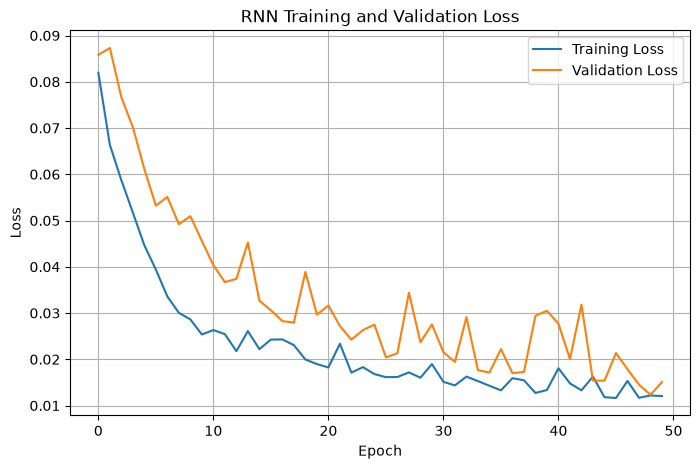

RNN loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_rnn_loss_graph.png


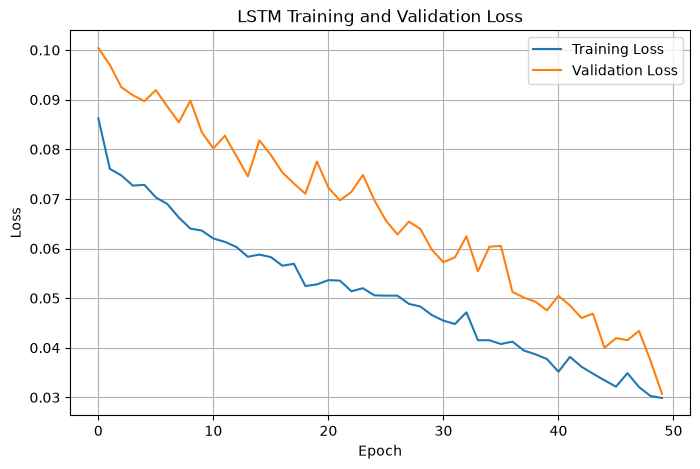

LSTM loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_lstm_loss_graph.png


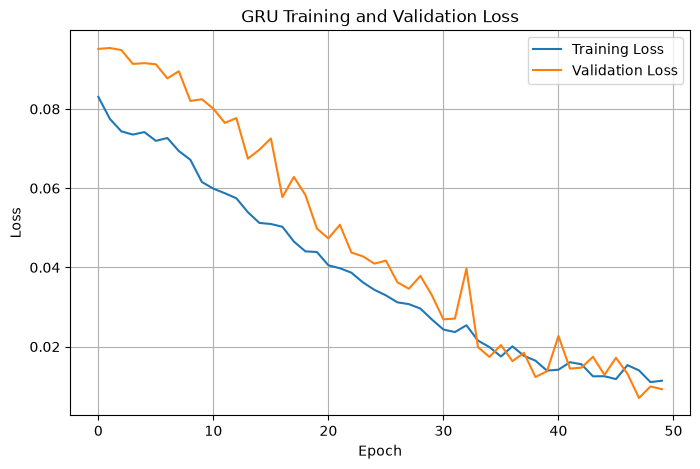

GRU loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_gru_loss_graph.png


In [21]:
# ============================================================
# Block 21: Plot training and validation loss graphs
# ============================================================

for model_name, history in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_{model_name.lower()}_loss_graph.png"
    )

    plt.savefig(loss_graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{model_name} loss graph saved at:", loss_graph_path)

In [22]:
# ============================================================
# Block 22: Evaluate all models
# ============================================================

evaluation_results = []
predictions_data = {}

for model_name, model in trained_models.items():
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()

    metrics, y_true_original, y_pred_original = evaluate_regression_model(
        model_name,
        y_test,
        y_pred_scaled
    )

    evaluation_results.append(metrics)

    predictions_data[model_name] = {
        "y_true": y_true_original,
        "y_pred": y_pred_original
    }

results_df = pd.DataFrame(evaluation_results)

display(results_df)

results_path = os.path.join(
    RESULTS_DIR,
    "phase3_rnn_lstm_gru_fertilizer_timeseries_results.csv"
)

results_df.to_csv(results_path, index=False)

print("Evaluation results saved at:", results_path)

,Model,MAE,MSE,RMSE,MAPE,R2_Score
0,RNN,3.912919,30.951255,5.563385,1887.485287,0.838824
1,LSTM,5.942242,63.005200,7.937582,4986.081681,0.671905
2,GRU,3.075307,18.968956,4.355336,1877.725261,0.901221


Evaluation results saved at: E:\AI Project\AgriMind_Project\results\phase3_fertilizer_timeseries\phase3_rnn_lstm_gru_fertilizer_timeseries_results.csv


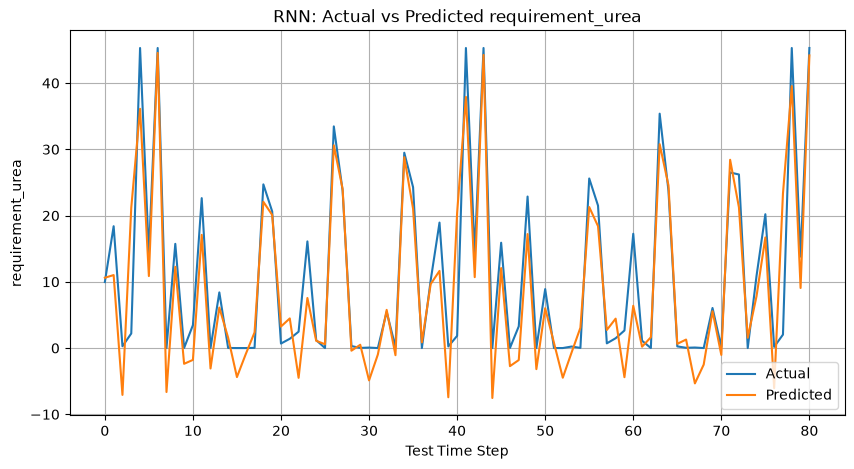

RNN actual vs predicted graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_rnn_actual_vs_predicted.png


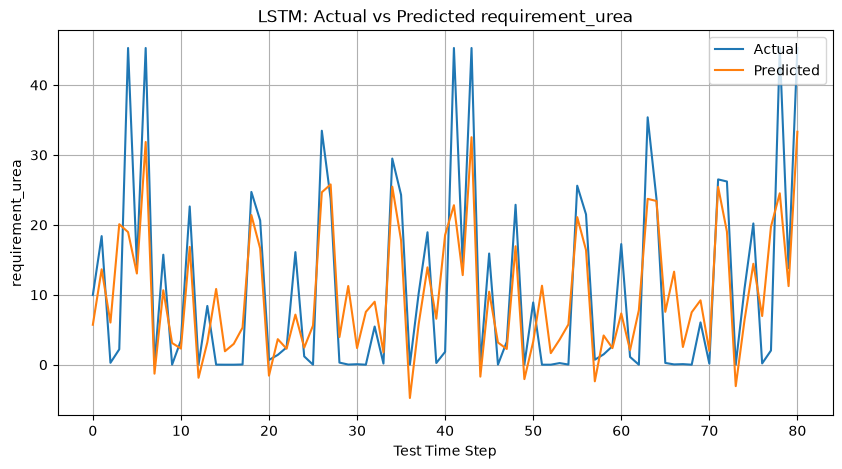

LSTM actual vs predicted graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_lstm_actual_vs_predicted.png


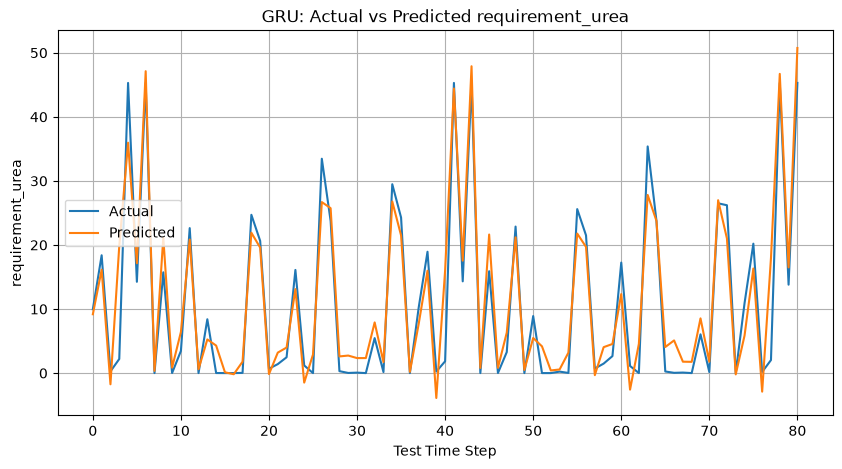

GRU actual vs predicted graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_gru_actual_vs_predicted.png


In [23]:
# ============================================================
# Block 23: Actual vs predicted graphs
# ============================================================

for model_name, data in predictions_data.items():
    plt.figure(figsize=(10, 5))
    plt.plot(data["y_true"], label="Actual")
    plt.plot(data["y_pred"], label="Predicted")
    plt.title(f"{model_name}: Actual vs Predicted {TARGET_COLUMN}")
    plt.xlabel("Test Time Step")
    plt.ylabel(TARGET_COLUMN)
    plt.legend()
    plt.grid(True)

    graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_{model_name.lower()}_actual_vs_predicted.png"
    )

    plt.savefig(graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{model_name} actual vs predicted graph saved at:", graph_path)

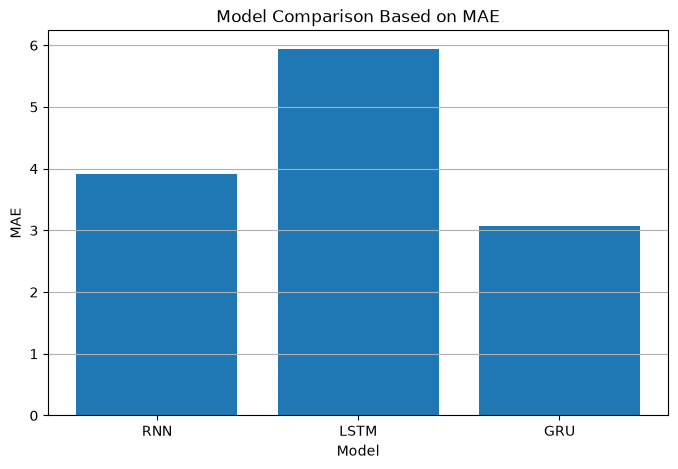

MAE comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_model_comparison_mae.png


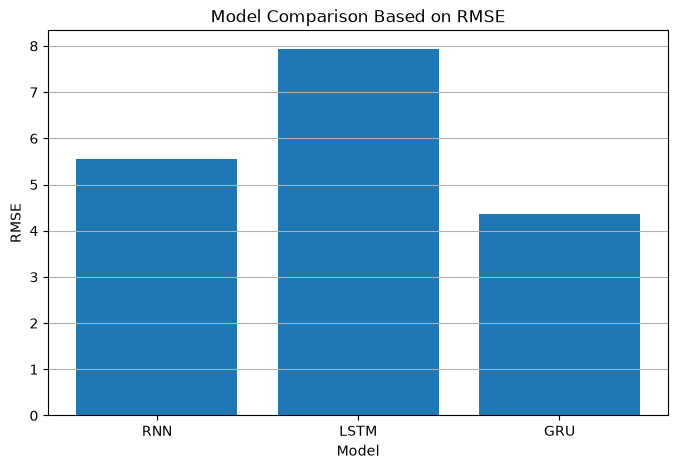

RMSE comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_model_comparison_rmse.png


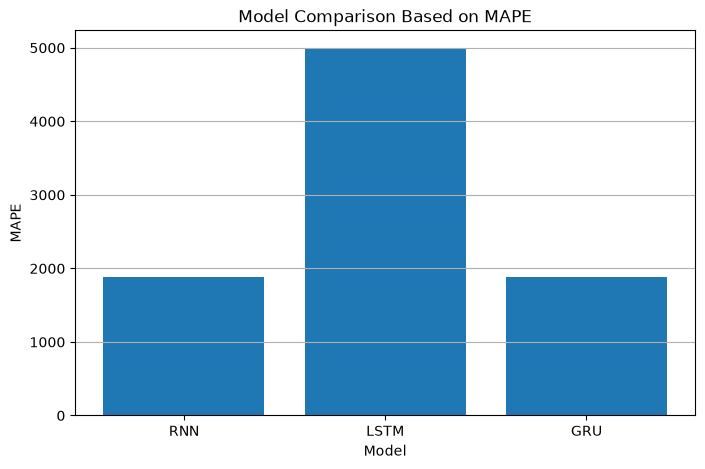

MAPE comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries\phase3_model_comparison_mape.png


In [24]:
# ============================================================
# Block 24: Model comparison graphs
# ============================================================

metrics_to_plot = ["MAE", "RMSE", "MAPE"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df["Model"], results_df[metric])
    plt.title(f"Model Comparison Based on {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(axis="y")

    comparison_graph_path = os.path.join(
        SCREENSHOTS_DIR,
        f"phase3_model_comparison_{metric.lower()}.png"
    )

    plt.savefig(comparison_graph_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{metric} comparison graph saved at:", comparison_graph_path)

In [25]:
# ============================================================
# Block 25: Select best model
# ============================================================

best_row = results_df.sort_values(by="RMSE", ascending=True).iloc[0]
BEST_MODEL_NAME = best_row["Model"]

print("Best model based on lowest RMSE:", BEST_MODEL_NAME)
print(best_row)

Best model based on lowest RMSE: GRU
Model               GRU
MAE            3.075307
MSE           18.968956
RMSE           4.355336
MAPE        1877.725261
R2_Score       0.901221
Name: 2, dtype: object


In [26]:
# ============================================================
# Block 26: Save trained models, scaler, encoders, and metadata
# ============================================================

for model_name, model in trained_models.items():
    model_path = os.path.join(
        MODEL_DIR,
        f"agrimind_phase3_{model_name.lower()}_fertilizer_timeseries.keras"
    )

    model.save(model_path)
    print(f"{model_name} model saved at:", model_path)

scaler_path = os.path.join(MODEL_DIR, "phase3_fertilizer_timeseries_scaler.pkl")

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

encoders_path = os.path.join(MODEL_DIR, "phase3_label_encoders.pkl")

with open(encoders_path, "wb") as f:
    pickle.dump(label_encoders, f)

metadata = {
    "dataset_source": DATASET_SOURCE,
    "main_dataset_path": REQUIREMENT_AVAILABILITY_SALES_FILE,
    "supporting_dataset_path": PRODUCTION_CAPACITY_FILE,
    "target_column": TARGET_COLUMN,
    "date_column": DATE_COLUMN,
    "sequence_length": SEQUENCE_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_model": BEST_MODEL_NAME,
    "model_names": list(trained_models.keys())
}

metadata_path = os.path.join(MODEL_DIR, "phase3_fertilizer_timeseries_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Scaler saved at:", scaler_path)
print("Label encoders saved at:", encoders_path)
print("Metadata saved at:", metadata_path)

RNN model saved at: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries\agrimind_phase3_rnn_fertilizer_timeseries.keras
LSTM model saved at: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries\agrimind_phase3_lstm_fertilizer_timeseries.keras
GRU model saved at: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries\agrimind_phase3_gru_fertilizer_timeseries.keras
Scaler saved at: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries\phase3_fertilizer_timeseries_scaler.pkl
Label encoders saved at: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries\phase3_label_encoders.pkl
Metadata saved at: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries\phase3_fertilizer_timeseries_metadata.json


In [27]:
# ============================================================
# Block 27: Save preprocessing and experiment report
# ============================================================

preprocessing_report = {
    "source_of_dataset": DATASET_SOURCE,
    "dataset_characteristics": dataset_characteristics,
    "main_dataset": "requirement_availability_sales_fertilisers_2014_to_2024.csv",
    "supporting_dataset": "fertiliser_production_capacity_2014_to_2024.csv",
    "preprocessing_steps": {
        "importing_libraries": True,
        "importing_datasets": True,
        "train_test_split": "80% train and 20% test chronological split",
        "handling_missing_values": "Numerical median and categorical mode",
        "treating_outliers": "IQR clipping on selected target column",
        "duplicate_records": "Removed using drop_duplicates",
        "feature_scaling": "MinMaxScaler",
        "handling_categorical_variables": "LabelEncoder used for categorical columns for completeness",
        "feature_selection": f"Selected {TARGET_COLUMN} as the time-series target feature"
    },
    "models_trained": ["RNN", "LSTM", "GRU"],
    "evaluation_metrics": ["MAE", "MSE", "RMSE", "MAPE", "R2 Score"],
    "best_model": BEST_MODEL_NAME
}

report_path = os.path.join(
    RESULTS_DIR,
    "phase3_fertilizer_timeseries_preprocessing_and_experiment_report.json"
)

with open(report_path, "w") as f:
    json.dump(preprocessing_report, f, indent=4)

print("Preprocessing and experiment report saved at:", report_path)

Preprocessing and experiment report saved at: E:\AI Project\AgriMind_Project\results\phase3_fertilizer_timeseries\phase3_fertilizer_timeseries_preprocessing_and_experiment_report.json


In [28]:
# ============================================================
# Block 28: Final summary
# ============================================================

print("============================================================")
print("AgriMind Phase 3 Fertilizer Time-Series Prediction Completed")
print("============================================================")
print("Main dataset:", REQUIREMENT_AVAILABILITY_SALES_FILE)
print("Supporting dataset:", PRODUCTION_CAPACITY_FILE)
print("Target column:", TARGET_COLUMN)
print("Date column:", DATE_COLUMN)
print("Best model:", BEST_MODEL_NAME)
print("Models folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)
print("============================================================")

display(results_df)

AgriMind Phase 3 Fertilizer Time-Series Prediction Completed
Main dataset: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Dataset\requirement_availability_sales_fertilisers_2014_to_2024.csv
Supporting dataset: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Dataset\fertiliser_production_capacity_2014_to_2024.csv
Target column: requirement_urea
Date column: financial_year
Best model: GRU
Models folder: E:\AI Project\AgriMind_Project\models\phase3_fertilizer_timeseries
Results folder: E:\AI Project\AgriMind_Project\results\phase3_fertilizer_timeseries
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase3_fertilizer_timeseries


,Model,MAE,MSE,RMSE,MAPE,R2_Score
0,RNN,3.912919,30.951255,5.563385,1887.485287,0.838824
1,LSTM,5.942242,63.005200,7.937582,4986.081681,0.671905
2,GRU,3.075307,18.968956,4.355336,1877.725261,0.901221
